# Experiment Analysis

Study  to find the most accurate and fastest parameter sets.

## 1. Load data

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("results/experiments.csv")

# Fix sign issue: some runs discovered negative R — treat magnitude only
df["R_discovered"] = df["R_discovered"].abs()

# Recompute error with corrected R
df["R_error_pct"] = ((df["R_discovered"] - df["R_true"]).abs() / df["R_true"] * 100).round(4)

# Total epochs as a lightweight cost proxy when duration is unavailable
df["total_epochs"] = df["pinn_epochs"] + df["parameter_discovery_epochs"]

print(df[["exp_id", "R_error_pct", "pinn_final_loss", "total_epochs"]].to_string(index=False))


exp_id  R_error_pct  pinn_final_loss  total_epochs
  exp1       0.1690         0.870159        130000
  exp2       0.0178         0.871180        130000
  exp3       0.0952         0.872140         80000
  exp4       0.1149         0.869801         80000
  exp5       0.1502         0.870748         80000
  exp6       0.0262         0.875427         80000
  exp7       0.0223         0.872563         80000
  exp8      51.5168         6.919318         60000
  exp9      99.9885      1659.670898         20000
 exp10       1.6754        21.732788        130000
 exp11       0.9900        21.787958        130000
 exp12       1.4569        21.770626         70000
 exp13       0.1845         0.875677         70000
 exp14       0.1273         0.880657         70000
 exp15       0.1690         0.870159        130000
 exp16       0.1273         0.880657         70000


## 2. Overview — all experiments

In [79]:
cols = [
    "exp_id", "physics_loss_discovery_randomize",
    "parameter_discovery_collocation_points",
    "parameter_discovery_loss_2_weight",
    "parameter_discovery_epochs",
    "noise_coeff",
    "R_discovered", "R_error_pct", "pinn_final_loss", "total_epochs"
]
df[cols].sort_values("R_error_pct")


,exp_id,physics_loss_discovery_randomize,parameter_discovery_collocation_points,parameter_discovery_loss_2_weight,parameter_discovery_epochs,noise_coeff,R_discovered,R_error_pct,pinn_final_loss,total_epochs
1,exp2,False,10000,100,100000,1,5.000892e-03,0.0178,0.871180,130000
6,exp7,True,10000,50,50000,1,5.001114e-03,0.0223,0.872563,80000
5,exp6,True,5000,50,50000,1,5.001310e-03,0.0262,0.875427,80000
2,exp3,False,10000,100,50000,1,4.995242e-03,0.0952,0.872140,80000
3,exp4,False,10000,50,50000,1,5.005744e-03,0.1149,0.869801,80000
15,exp16,True,10000,100,40000,1,4.993635e-03,0.1273,0.880657,70000
13,exp14,True,10000,100,40000,1,4.993635e-03,0.1273,0.880657,70000
4,exp5,False,5000,50,50000,1,4.992490e-03,0.1502,0.870748,80000
14,exp15,True,10000,100,100000,1,5.008450e-03,0.1690,0.870159,130000
0,exp1,True,10000,100,100000,1,5.008450e-03,0.1690,0.870159,130000


In [80]:
# ── Drop duplicate parameter sets, keep the most accurate run ────────────────
param_cols = [
    "number_of_points", "noise_coeff",
    "pinn_collocation_points", "parameter_discovery_collocation_points",
    "pinn_loss2_weight", "parameter_discovery_loss_2_weight",
    "physics_loss_discovery_randomize", "pinn_epochs", "parameter_discovery_epochs",
]

df = (
    df.sort_values("R_error_pct")           # best accuracy first
      .drop_duplicates(subset=param_cols)    # keep first (= best) of each duplicate group
      .reset_index(drop=True)
)

print(f"{len(df)} unique parameter sets remaining")
df[cols].sort_values("R_error_pct")

14 unique parameter sets remaining


,exp_id,physics_loss_discovery_randomize,parameter_discovery_collocation_points,parameter_discovery_loss_2_weight,parameter_discovery_epochs,noise_coeff,R_discovered,R_error_pct,pinn_final_loss,total_epochs
0,exp2,False,10000,100,100000,1,5.000892e-03,0.0178,0.871180,130000
1,exp7,True,10000,50,50000,1,5.001114e-03,0.0223,0.872563,80000
2,exp6,True,5000,50,50000,1,5.001310e-03,0.0262,0.875427,80000
3,exp3,False,10000,100,50000,1,4.995242e-03,0.0952,0.872140,80000
4,exp4,False,10000,50,50000,1,5.005744e-03,0.1149,0.869801,80000
5,exp16,True,10000,100,40000,1,4.993635e-03,0.1273,0.880657,70000
6,exp5,False,5000,50,50000,1,4.992490e-03,0.1502,0.870748,80000
7,exp15,True,10000,100,100000,1,5.008450e-03,0.1690,0.870159,130000
8,exp13,False,10000,100,40000,1,4.990777e-03,0.1845,0.875677,70000
9,exp11,True,1000,100,100000,5,5.049501e-03,0.9900,21.787958,130000


## 3. Most accurate runs

Lowest .

In [81]:
top_accurate = df.nsmallest(5, "R_error_pct")[cols]
print("Top 5 most accurate:")
top_accurate.head()


Top 5 most accurate:


,exp_id,physics_loss_discovery_randomize,parameter_discovery_collocation_points,parameter_discovery_loss_2_weight,parameter_discovery_epochs,noise_coeff,R_discovered,R_error_pct,pinn_final_loss,total_epochs
0,exp2,False,10000,100,100000,1,0.005001,0.0178,0.871180,130000
1,exp7,True,10000,50,50000,1,0.005001,0.0223,0.872563,80000
2,exp6,True,5000,50,50000,1,0.005001,0.0262,0.875427,80000
3,exp3,False,10000,100,50000,1,0.004995,0.0952,0.872140,80000
4,exp4,False,10000,50,50000,1,0.005006,0.1149,0.869801,80000


## 4. Best accuracy vs speed

Runs with low error AND low total epochs — the sweet spot.

In [82]:
# Normalise both metrics to [0,1] then compute combined score (lower = better)
df["norm_error"]  = (df["R_error_pct"]  - df["R_error_pct"].min())  / (df["R_error_pct"].max()  - df["R_error_pct"].min() + 1e-9)
df["norm_epochs"] = (df["total_epochs"] - df["total_epochs"].min()) / (df["total_epochs"].max() - df["total_epochs"].min() + 1e-9)

# Equal weight — change 0.5/0.5 to bias toward accuracy or speed
df["combined_score"] = 0.5 * df["norm_error"] + 0.5 * df["norm_epochs"]

best = df.nsmallest(5, "combined_score")[["exp_id", "R_error_pct", "total_epochs", "combined_score"]]
print("Top 5 accuracy+speed:")
print(best.to_string(index=False))


Top 5 accuracy+speed:
exp_id  R_error_pct  total_epochs  combined_score
 exp16       0.1273         70000        0.227820
 exp13       0.1845         70000        0.228106
 exp12       1.4569         70000        0.234470
  exp7       0.0223         80000        0.272750
  exp6       0.0262         80000        0.272769


## 5. Plots

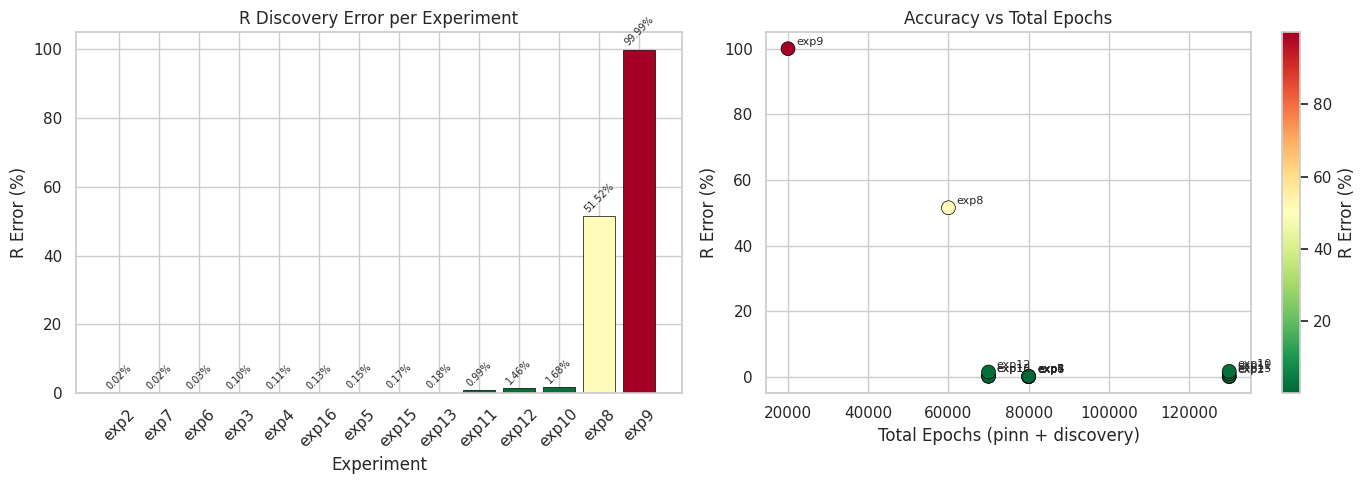

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — R error per exp —
ax = axes[0]
colors = cm.RdYlGn_r(df["R_error_pct"] / df["R_error_pct"].max())
bars = ax.bar(df["exp_id"], df["R_error_pct"], color=colors, edgecolor="black", lw=0.5)
for bar, v in zip(bars, df["R_error_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{v:.2f}%", ha="center", va="bottom", fontsize=7, rotation=45)
ax.set_title("R Discovery Error per Experiment")
ax.set_xlabel("Experiment")
ax.set_ylabel("R Error (%)")
ax.tick_params(axis="x", rotation=45)

# — Epochs vs error scatter —
ax = axes[1]
sc = ax.scatter(df["total_epochs"], df["R_error_pct"],
                c=df["R_error_pct"], cmap="RdYlGn_r", s=100, edgecolors="black", lw=0.5, zorder=3)
for _, row in df.iterrows():
    ax.annotate(row["exp_id"], (row["total_epochs"], row["R_error_pct"]),
                textcoords="offset points", xytext=(6, 3), fontsize=8)
fig.colorbar(sc, ax=ax, label="R Error (%)")
ax.set_title("Accuracy vs Total Epochs")
ax.set_xlabel("Total Epochs (pinn + discovery)")
ax.set_ylabel("R Error (%)")

plt.tight_layout()
plt.show()


## 6. How individual parameters affect accuracy

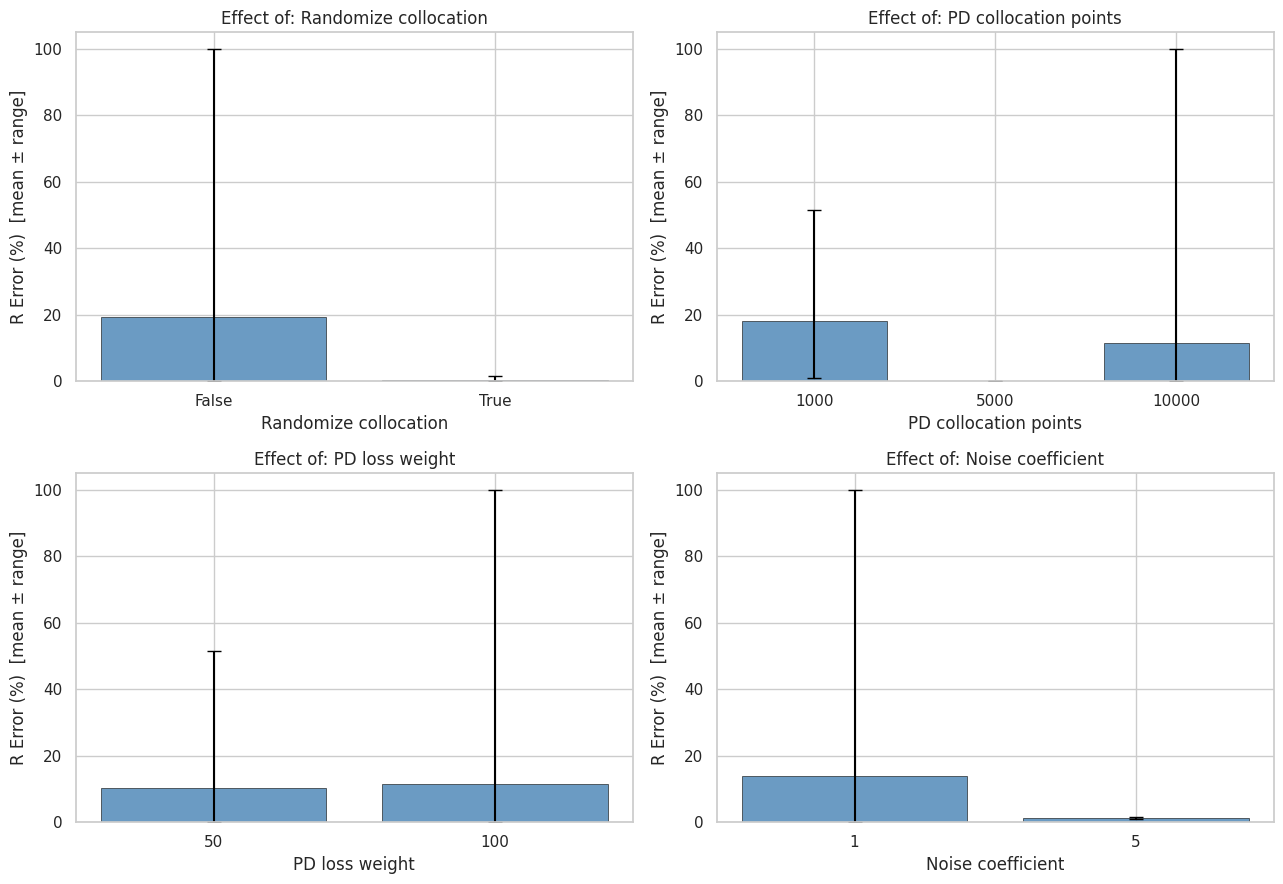

In [84]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

params_to_study = [
    ("physics_loss_discovery_randomize",        "Randomize collocation"),
    ("parameter_discovery_collocation_points",  "PD collocation points"),
    ("parameter_discovery_loss_2_weight",       "PD loss weight"),
    ("noise_coeff",                             "Noise coefficient"),
]

for ax, (col, label) in zip(axes.flat, params_to_study):
    grouped = df.groupby(col)["R_error_pct"].agg(["mean", "min", "max"]).reset_index()
    x = grouped[col].astype(str)
    ax.bar(x, grouped["mean"], color="steelblue", alpha=0.8, label="mean", edgecolor="black", lw=0.5)
    ax.errorbar(x, grouped["mean"],
                yerr=[grouped["mean"] - grouped["min"], grouped["max"] - grouped["mean"]],
                fmt="none", color="black", capsize=5, lw=1.5)
    ax.set_title(f"Effect of: {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("R Error (%)  [mean ± range]")

plt.tight_layout()
plt.show()


## 7. Heatmap — collocation points × loss weight

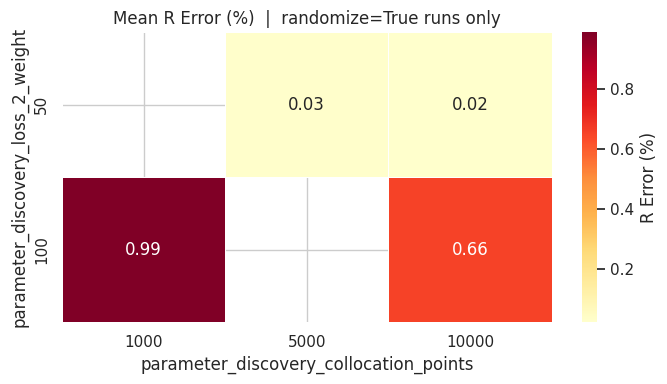

In [85]:
pivot_data = df[df["physics_loss_discovery_randomize"] == True].copy()

if len(pivot_data) >= 2:
    pivot = pivot_data.pivot_table(
        index="parameter_discovery_loss_2_weight",
        columns="parameter_discovery_collocation_points",
        values="R_error_pct",
        aggfunc="mean"
    )
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd",
                linewidths=0.5, ax=ax, cbar_kws={"label": "R Error (%)"})
    ax.set_title("Mean R Error (%)  |  randomize=True runs only")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough randomize=True runs for a heatmap yet — run more experiments!")


## 8. Recommendation

Prints the single best config for accuracy, and the best balanced config.

In [86]:
best_accurate = df.loc[df["R_error_pct"].idxmin()]
best_balanced = df.loc[df["combined_score"].idxmin()]

param_cols = [
    "number_of_points", "noise_coeff",
    "pinn_collocation_points", "parameter_discovery_collocation_points",
    "pinn_loss2_weight", "parameter_discovery_loss_2_weight",
    "physics_loss_discovery_randomize",
    "pinn_epochs", "parameter_discovery_epochs",
]

print("=" * 55)
print(f" BEST ACCURACY  →  {best_accurate['exp_id']}  |  R_error = {best_accurate['R_error_pct']:.4f}%")
print("=" * 55)
for c in param_cols:
    print(f"  {c:<48} {best_accurate[c]}")

print()
print("=" * 55)
print(f" BEST BALANCED  →  {best_balanced['exp_id']}  |  R_error = {best_balanced['R_error_pct']:.4f}%  |  total_epochs = {int(best_balanced['total_epochs'])}")
print("=" * 55)
for c in param_cols:
    print(f"  {c:<48} {best_balanced[c]}")


 BEST ACCURACY  →  exp2  |  R_error = 0.0178%
  number_of_points                                 1000
  noise_coeff                                      1
  pinn_collocation_points                          5000
  parameter_discovery_collocation_points           10000
  pinn_loss2_weight                                50
  parameter_discovery_loss_2_weight                100
  physics_loss_discovery_randomize                 False
  pinn_epochs                                      30000
  parameter_discovery_epochs                       100000

 BEST BALANCED  →  exp16  |  R_error = 0.1273%  |  total_epochs = 70000
  number_of_points                                 1000
  noise_coeff                                      1
  pinn_collocation_points                          5000
  parameter_discovery_collocation_points           10000
  pinn_loss2_weight                                50
  parameter_discovery_loss_2_weight                100
  physics_loss_discovery_randomize             